In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel(r'D:\Projects\bj_food_analysis\bj_food_analysis.xlsx')
print("形状:", df.shape)
print("\n前3行:\n", df.head(3))
print("\n列名:\n", df.columns.tolist())


形状: (44512, 16)

前3行:
        店铺id                   店铺名称          经度         纬度  人均消费   评分  评论数量  \
0  20602249                   杨家火锅  116.408198  39.904667     0  5.0     1   
1   7041367              皇家鸡排(云岗店)  116.408250  39.904660    17  NaN     0   
2    336543  麦当劳 北辰居住区店 McDonald's  116.407410  39.904213     0  4.1    11   

        距离描述 米其林推荐指数 归属商圈  菜系类型 city county         营业时间                 地址  \
0  距市中心<100m     NaN  NaN    火锅   北京    东城区  休息中 11:00营业         城内汇文金街7号商铺   
1  距市中心<100m     NaN  NaN  快餐简餐   北京    东城区          NaN               云岗东路   
2  距市中心<100m     NaN  NaN  快餐简餐   北京    东城区          NaN  北苑北辰居住区B5区近北辰购物中心   

              店铺电话  
0  ['15383160018']  
1  ['13522544796']  
2              NaN  

列名:
 ['店铺id', '店铺名称', '经度', '纬度', '人均消费', '评分', '评论数量', '距离描述', '米其林推荐指数', '归属商圈', '菜系类型', 'city', 'county', '营业时间', '地址', '店铺电话']


In [7]:
print("=== info ===")
df.info()
print("\n=== 评分概况 ===")
print(df['评分'].describe())
print("\n=== 人均消费概况 ===")
print(df['人均消费'].describe())
print("\n=== 菜系类型数量 ===")
print(df['菜系类型'].value_counts().head(10))
print("\n=== 区域分布 ===")
print(df['county'].value_counts().head(10))


=== info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44512 entries, 0 to 44511
Data columns (total 16 columns):
店铺id       44512 non-null int64
店铺名称       44512 non-null object
经度         44512 non-null float64
纬度         44512 non-null float64
人均消费       44512 non-null int64
评分         17449 non-null float64
评论数量       44512 non-null int64
距离描述       35645 non-null object
米其林推荐指数    422 non-null object
归属商圈       36784 non-null object
菜系类型       39954 non-null object
city       44512 non-null object
county     44512 non-null object
营业时间       32178 non-null object
地址         44512 non-null object
店铺电话       39502 non-null object
dtypes: float64(3), int64(3), object(10)
memory usage: 5.4+ MB

=== 评分概况 ===
count    17449.000000
mean         4.529910
std          0.522466
min          1.000000
25%          4.300000
50%          4.600000
75%          5.000000
max          5.000000
Name: 评分, dtype: float64

=== 人均消费概况 ===
count    44512.000000
mean        60.665731
std        106

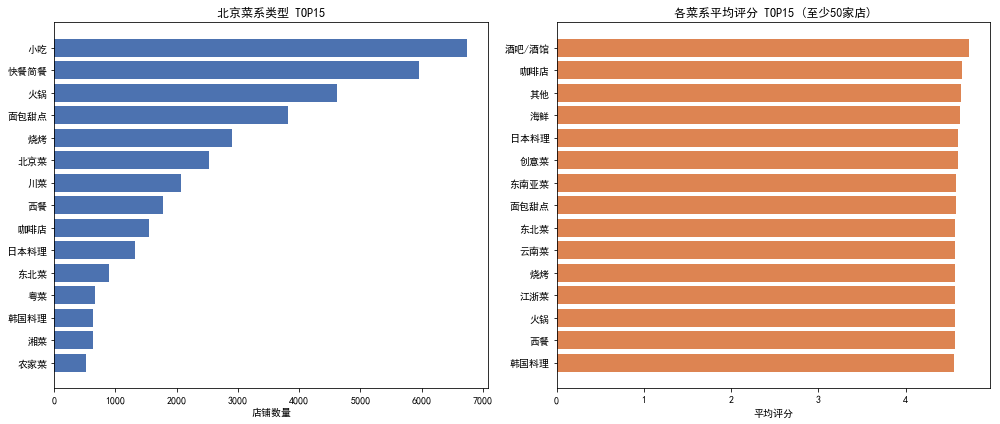

各菜系统计:
小吃      6740
快餐简餐    5955
火锅      4622
面包甜点    3822
烧烤      2910
北京菜     2533
川菜      2073
西餐      1769
咖啡店     1555
日本料理    1317
东北菜      897
粤菜       667
韩国料理     632
湘菜       628
农家菜      518
Name: 菜系类型, dtype: int64


In [8]:
# === 菜系 TOP15 ===
cuisine_cnt = df['菜系类型'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(cuisine_cnt.index[::-1], cuisine_cnt.values[::-1], color='#4C72B0')
axes[0].set_title('北京菜系类型 TOP15')
axes[0].set_xlabel('店铺数量')

# 各菜系平均评分
cuisine_score = df.groupby('菜系类型')['评分'].agg(['count', 'mean']).round(2)
cuisine_top = cuisine_score[cuisine_score['count'] >= 50].sort_values('mean', ascending=False).head(15)
axes[1].barh(cuisine_top.index[::-1], cuisine_top['mean'][::-1], color='#DD8452')
axes[1].set_title('各菜系平均评分 TOP15 (至少50家店)')
axes[1].set_xlabel('平均评分')

plt.tight_layout()
plt.show()
print("各菜系统计:")
print(cuisine_cnt)



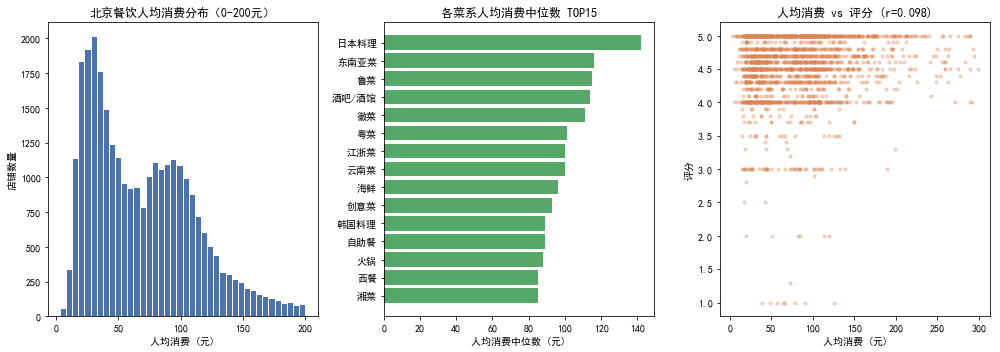

In [9]:
# === 人均消费分布 ===
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 左：人均消费分布直方图（限0-200元）
df_price = df[(df['人均消费'] > 0) & (df['人均消费'] <= 200)]
axes[0].hist(df_price['人均消费'], bins=40, color='#4C72B0', edgecolor='white')
axes[0].set_title('北京餐饮人均消费分布（0-200元）')
axes[0].set_xlabel('人均消费 (元)')
axes[0].set_ylabel('店铺数量')

# 中：各菜系人均消费中位数 TOP15
cuisine_price = df.groupby('菜系类型')['人均消费'].agg(['count', 'median']).round(0)
cuisine_price_top = cuisine_price[cuisine_price['count'] >= 50].sort_values('median', ascending=False).head(15)
axes[1].barh(cuisine_price_top.index[::-1], cuisine_price_top['median'][::-1], color='#55A868')
axes[1].set_title('各菜系人均消费中位数 TOP15')
axes[1].set_xlabel('人均消费中位数 (元)')

# 右：人均消费 vs 评分
df_sample = df[(df['评分'].notna()) & (df['人均消费'] > 0) & (df['人均消费'] <= 300)].sample(2000)
axes[2].scatter(df_sample['人均消费'], df_sample['评分'], alpha=0.3, c='#DD8452', s=10)
r = df_sample['人均消费'].corr(df_sample['评分'])
axes[2].set_xlabel('人均消费 (元)')
axes[2].set_ylabel('评分')
axes[2].set_title(f'人均消费 vs 评分 (r={r:.3f})')

plt.tight_layout()
plt.show()


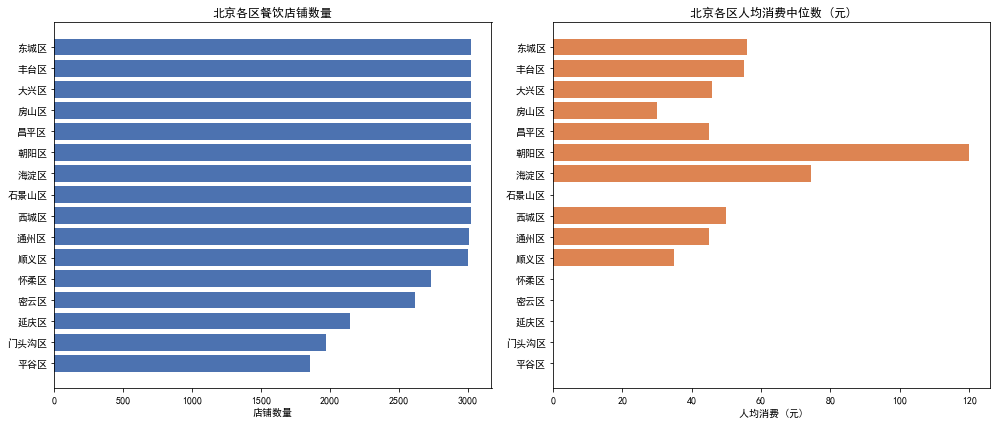

        店铺数量  平均评分  人均消费中位数
county                     
东城区     3020  4.53     56.0
丰台区     3020  4.55     55.0
大兴区     3020  4.47     46.0
房山区     3020  4.55     30.0
昌平区     3020  4.49     45.0
朝阳区     3020  4.63    120.0
海淀区     3020  4.49     74.5
石景山区    3020  4.45      0.0
西城区     3020  4.52     50.0
通州区     3006  4.55     45.0
顺义区     3002  4.51     35.0
怀柔区     2732  4.58      0.0
密云区     2618  4.59      0.0
延庆区     2148  4.39      0.0
门头沟区    1970  4.63      0.0


In [12]:
# === 各区店铺数量和评分 ===
county_stats = df.groupby('county').agg({
    '店铺id': 'count',
    '评分': 'mean',
    '人均消费': 'median'
}).round(2)
county_stats.columns = ['店铺数量', '平均评分', '人均消费中位数']
county_stats = county_stats.sort_values('店铺数量', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(county_stats.index[::-1], county_stats['店铺数量'][::-1], color='#4C72B0')
axes[0].set_title('北京各区餐饮店铺数量')
axes[0].set_xlabel('店铺数量')

axes[1].barh(county_stats.index[::-1], county_stats['人均消费中位数'][::-1], color='#DD8452')
axes[1].set_title('北京各区人均消费中位数 (元)')
axes[1].set_xlabel('人均消费 (元)')

plt.tight_layout()
plt.show()

print(county_stats.head(15))



北京餐饮行业数据分析

数据概况
  44,512 家北京餐饮店铺
  评分缺失约 60%，人均消费中位数 37 元
  数据按区域均衡采样，每区约 3,000 条
    
核心发现
 1.小吃是第一大品类
  小吃 6,740 家、快餐简餐 5,955 家、火锅 4,622 家位列前三
  北京餐饮市场以低价高频消费为主

人均消费集中在低价段
  中位数 37 元，75% 的店人均不到 88 元
  人均消费与评分相关性极低——贵的不代表好吃

3.各区差异明显
  朝阳区人均消费中位数最高（120 元），是房山（30 元）的 4 倍
  评分各区差异不大，普遍在 4.3-4.7 之间

4.评分缺失是普遍问题
  仅 17,449/44,512 家有评分（39%），实际口碑数据更少

结论
  北京餐饮市场品类丰富，价格亲民。朝阳区是高端餐饮集中地，小吃快餐是市场绝对主力。
